# Stage 6: Hotspot and Persistence Scoring



In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Import the libraries

I only need a few main libraries for this stage.

In [19]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [20]:
# This makes wider tables easier to read in Colab

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 3. Set the file paths

I am using the Stage 5 GeoPackage as the main input.

In [21]:
input_file = "/content/drive/MyDrive/disseration/stage5_outputs/grid_year_5km_analysis.gpkg"
input_layer = "grid_year_analysis"

output_folder = "/content/drive/MyDrive/disseration/stage6_outputs"
map_folder = os.path.join(output_folder, "maps")

In [22]:
# Create folders for this stage

os.makedirs(output_folder, exist_ok=True)
os.makedirs(map_folder, exist_ok=True)

print("Input file:")
print(input_file)

print("\nOutput folder:")
print(output_folder)

Input file:
/content/drive/MyDrive/disseration/stage5_outputs/grid_year_5km_analysis.gpkg

Output folder:
/content/drive/MyDrive/disseration/stage6_outputs


## 4. Load the Stage 5 grid-year data

In [23]:
grid_year = gpd.read_file(
    input_file,
    layer=input_layer
)

In [24]:
print("Rows:", len(grid_year))
print("Columns:", len(grid_year.columns))

grid_year.head()

Rows: 38030
Columns: 17


,grid_id,year,collision_count,fatal_count,serious_count,slight_count,total_severity_score,mean_severity_score,occupied_in_year,zero_collision_year,grid_row,grid_col,cell_size_m,cell_area_km2,centroid_easting,centroid_northing,geometry
0,R000_C005,2020,0,0,0,0,0.000,NaN,0,1,0,5,5000,25.000,"92,500.000","12,500.000","POLYGON ((95000 10000, 95000 15000, 90000 1500..."
1,R000_C005,2021,0,0,0,0,0.000,NaN,0,1,0,5,5000,25.000,"92,500.000","12,500.000","POLYGON ((95000 10000, 95000 15000, 90000 1500..."
2,R000_C005,2022,2,0,0,2,2.000,1.000,1,0,0,5,5000,25.000,"92,500.000","12,500.000","POLYGON ((95000 10000, 95000 15000, 90000 1500..."
3,R000_C005,2023,3,0,1,2,4.000,1.333,1,0,0,5,5000,25.000,"92,500.000","12,500.000","POLYGON ((95000 10000, 95000 15000, 90000 1500..."
4,R000_C005,2024,2,0,2,0,4.000,2.000,1,0,0,5,5000,25.000,"92,500.000","12,500.000","POLYGON ((95000 10000, 95000 15000, 90000 1500..."


I first want to see the column names before assuming which columns contain the year and collision count.

In [25]:
grid_year.columns.tolist()

['grid_id',
 'year',
 'collision_count',
 'fatal_count',
 'serious_count',
 'slight_count',
 'total_severity_score',
 'mean_severity_score',
 'occupied_in_year',
 'zero_collision_year',
 'grid_row',
 'grid_col',
 'cell_size_m',
 'cell_area_km2',
 'centroid_easting',
 'centroid_northing',
 'geometry']

## 5. Short checks before starting the scoring

I already checked the data in detail in Stages 1 to 5, so here I am only checking the main things needed for this stage.

In [26]:
print("CRS:", grid_year.crs)
print("Geometry types:", grid_year.geometry.geom_type.unique())
print("Missing geometries:", grid_year.geometry.isna().sum())

CRS: EPSG:27700
Geometry types: ['Polygon']
Missing geometries: 0


In [27]:
# All spatial work should be in British National Grid

if grid_year.crs is None:
    raise ValueError("The data has no CRS.")

if grid_year.crs.to_epsg() != 27700:
    print("The data is not in EPSG:27700, so I am converting it.")
    grid_year = grid_year.to_crs(epsg=27700)
else:
    print("The CRS is already EPSG:27700.")

The CRS is already EPSG:27700.


## 6. Find the year and collision-count columns

I used slightly different names in some earlier notebooks, so I am checking a few possible names.

In [28]:
year_options = [
    "year",
    "accident_year",
    "collision_year"
]

count_options = [
    "collision_count",
    "yearly_collision_count",
    "total_collisions",
    "accident_count",
    "number_of_collisions"
]

In [29]:
year_col = None

for col in year_options:
    if col in grid_year.columns:
        year_col = col
        break

count_col = None

for col in count_options:
    if col in grid_year.columns:
        count_col = col
        break

print("Year column:", year_col)
print("Collision-count column:", count_col)

Year column: year
Collision-count column: collision_count


In [30]:
if year_col is None:
    raise KeyError("I could not find the year column. Check the column list above.")

if count_col is None:
    raise KeyError("I could not find the collision-count column. Check the column list above.")

To keep the remaining code simple, I am renaming the two main variables to `year` and `collision_count`.

In [31]:
if year_col != "year":
    grid_year = grid_year.rename(columns={year_col: "year"})

if count_col != "collision_count":
    grid_year = grid_year.rename(columns={count_col: "collision_count"})

In [32]:
# Convert them to numeric values

grid_year["year"] = pd.to_numeric(
    grid_year["year"],
    errors="coerce"
)

grid_year["collision_count"] = pd.to_numeric(
    grid_year["collision_count"],
    errors="coerce"
)

In [33]:
print("Missing year values:", grid_year["year"].isna().sum())
print("Missing collision counts:", grid_year["collision_count"].isna().sum())

Missing year values: 0
Missing collision counts: 0


If the collision count is missing, I will treat it as zero because the Stage 5 table was designed to include zero-collision years.

In [34]:
grid_year["collision_count"] = (
    grid_year["collision_count"]
    .fillna(0)
    .astype(int)
)

grid_year["year"] = grid_year["year"].astype(int)
grid_year["grid_id"] = grid_year["grid_id"].astype(str)

## 7. Check the years and number of grid cells

In [35]:
study_years = [2020, 2021, 2022, 2023, 2024]

print("Years found:", sorted(grid_year["year"].unique()))
print("Unique grid cells:", grid_year["grid_id"].nunique())

Years found: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique grid cells: 7606


In [36]:
grid_year["year"].value_counts().sort_index()

,count
year,
2020,7606
2021,7606
2022,7606
2023,7606
2024,7606


Each grid cell should appear once in every year. I will check that now.

In [37]:
years_per_grid = (
    grid_year.groupby("grid_id")["year"]
    .nunique()
)

years_per_grid.value_counts().sort_index()

,count
year,
5,7606


In [38]:
print("Minimum years per grid:", years_per_grid.min())
print("Maximum years per grid:", years_per_grid.max())
print("Duplicate grid-year rows:", grid_year.duplicated(["grid_id", "year"]).sum())

Minimum years per grid: 5
Maximum years per grid: 5
Duplicate grid-year rows: 0


In [39]:
if not years_per_grid.eq(5).all():
    raise ValueError("Some grid cells do not have five yearly records.")

if grid_year.duplicated(["grid_id", "year"]).any():
    raise ValueError("Duplicate grid-year records were found.")

print("The grid-year structure looks correct.")

The grid-year structure looks correct.


## 8. Look at the collision-count distribution

Before deciding the hotspot threshold, I want to see how the yearly collision counts are distributed.

In [40]:
yearly_count_summary = (
    grid_year.groupby("year")["collision_count"]
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

yearly_count_summary

,count,mean,std,min,50%,75%,90%,95%,99%,max
year,,,,,,,,,,
2020,"7,606.000",11.990,44.810,0.000,3.000,8.000,25.000,46.750,152.000,"1,182.000"
2021,"7,606.000",13.290,50.940,0.000,3.000,9.000,27.000,53.000,174.000,"1,495.000"
2022,"7,606.000",13.930,51.820,0.000,3.000,9.000,28.000,55.000,185.800,"1,497.000"
2023,"7,606.000",13.710,50.760,0.000,3.000,9.000,28.000,54.000,183.950,"1,409.000"
2024,"7,606.000",13.270,46.730,0.000,3.000,9.000,27.000,53.000,180.950,"1,344.000"


The 90th percentile represents the top 10% area and the 95th percentile represents the top 5% area. I will compare both before selecting the main rule.

/tmp/ipykernel_810/1640389960.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


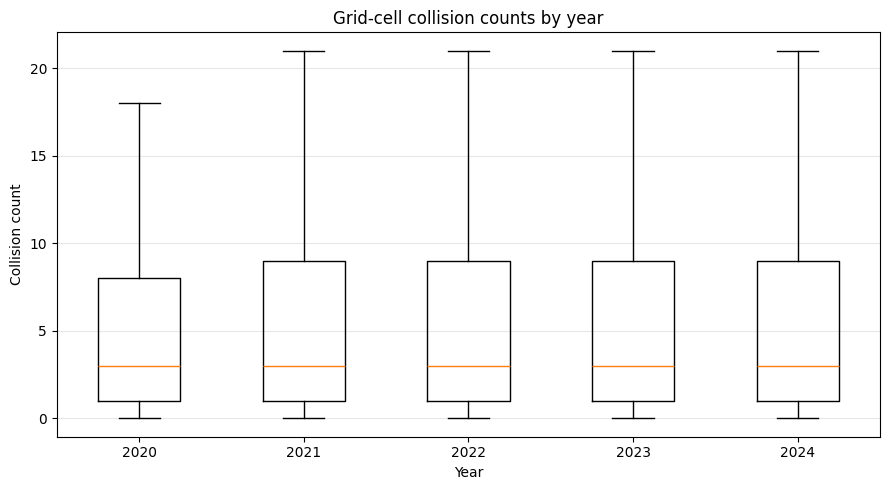

In [41]:
plt.figure(figsize=(9, 5))

boxplot_data = []

for year in study_years:
    values = grid_year.loc[
        grid_year["year"] == year,
        "collision_count"
    ]

    boxplot_data.append(values)

plt.boxplot(
    boxplot_data,
    labels=study_years,
    showfliers=False
)

plt.title("Grid-cell collision counts by year")
plt.xlabel("Year")
plt.ylabel("Collision count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

boxplot_file = os.path.join(
    map_folder,
    "collision_count_boxplot_by_year.png"
)

plt.savefig(
    boxplot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### My note after running this cell

The distribution should be right-skewed, with many low-count grid cells and a smaller number of high-count cells. I will use the percentile results below to confirm this.

## 9. Check zero-collision records

Zero-collision records are useful for measuring persistence because they show years when a grid cell was inactive.

In [42]:
total_records = len(grid_year)

zero_records = (
    grid_year["collision_count"] == 0
).sum()

zero_percentage = (
    zero_records / total_records
) * 100

print("Total grid-year records:", total_records)
print("Zero-collision records:", zero_records)
print("Zero-collision percentage:", round(zero_percentage, 2))

Total grid-year records: 38030
Zero-collision records: 7650
Zero-collision percentage: 20.12


In [43]:
zero_by_year = (
    grid_year.groupby("year")
    .agg(
        total_cells=("grid_id", "size"),
        zero_collision_cells=(
            "collision_count",
            lambda x: (x == 0).sum()
        ),
        occupied_cells=(
            "collision_count",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

zero_by_year["zero_collision_percentage"] = (
    zero_by_year["zero_collision_cells"]
    / zero_by_year["total_cells"]
    * 100
)

zero_by_year.round(2)

,year,total_cells,zero_collision_cells,occupied_cells,zero_collision_percentage
0,2020,7606,1659,5947,21.810
1,2021,7606,1538,6068,20.220
2,2022,7606,1513,6093,19.890
3,2023,7606,1471,6135,19.340
4,2024,7606,1469,6137,19.310


## 10. Decide what a hotspot means in this stage

For this notebook:

- A **high collision count** means a cell has a large raw count.
- A **hotspot** means a cell is in the highest part of the yearly distribution.
- A **persistent hotspot** means the same cell is repeatedly a hotspot across the five years.
- An **emerging hotspot** appears mainly in the later years.
- A **declining hotspot** appears mainly in the early years.
- An **intermittent hotspot** appears in some years without a clear direction.

This is a descriptive hotspot definition. It does not yet show statistically significant spatial clustering.

## 11. Compare top 10% and top 5%

I will calculate both options first. This helps me see whether the top 5% creates too few hotspot cells.

In [44]:
threshold_rows = []

for year in study_years:

    occupied_counts = grid_year.loc[
        (grid_year["year"] == year) &
        (grid_year["collision_count"] > 0),
        "collision_count"
    ]

    top_10_cutoff = occupied_counts.quantile(
        0.90,
        interpolation="higher"
    )

    top_5_cutoff = occupied_counts.quantile(
        0.95,
        interpolation="higher"
    )

    top_10_cells = (
        occupied_counts >= top_10_cutoff
    ).sum()

    top_5_cells = (
        occupied_counts >= top_5_cutoff
    ).sum()

    threshold_rows.append({
        "year": year,
        "occupied_cells": len(occupied_counts),
        "top_10_cutoff": int(top_10_cutoff),
        "top_10_cells": int(top_10_cells),
        "top_5_cutoff": int(top_5_cutoff),
        "top_5_cells": int(top_5_cells)
    })

In [45]:
threshold_comparison = pd.DataFrame(
    threshold_rows
)

threshold_comparison

,year,occupied_cells,top_10_cutoff,top_10_cells,top_5_cutoff,top_5_cells
0,2020,5947,32,601,58,299
1,2021,6068,34,612,64,305
2,2022,6093,36,610,67,313
3,2023,6135,35,629,65,307
4,2024,6137,34,629,63,308


### Threshold decision

I will use the **top 10% of occupied grid cells in each year**.

I selected this because it gives a larger and more stable group for later modelling. The top 5% can still be tested later as a sensitivity check.

Because collision counts are whole numbers, tied values may mean that slightly more than 10% of occupied cells are selected.

## 12. Calculate the selected yearly thresholds

In [46]:
hotspot_quantile = 0.90

selected_thresholds = []

In [47]:
for year in study_years:

    occupied_counts = grid_year.loc[
        (grid_year["year"] == year) &
        (grid_year["collision_count"] > 0),
        "collision_count"
    ]

    cutoff = occupied_counts.quantile(
        hotspot_quantile,
        interpolation="higher"
    )

    selected_thresholds.append({
        "year": year,
        "hotspot_count_threshold": int(cutoff)
    })

In [48]:
yearly_thresholds = pd.DataFrame(
    selected_thresholds
)

yearly_thresholds

,year,hotspot_count_threshold
0,2020,32
1,2021,34
2,2022,36
3,2023,35
4,2024,34


## 13. Create a yearly percentile score

I also want a score that shows where each cell sits in the yearly distribution.

A percentile score of 95 means that the cell has a higher count than roughly 95% of occupied cells in that year.

In [49]:
grid_year["collision_percentile"] = 0.0

In [50]:
for year in study_years:

    occupied_mask = (
        (grid_year["year"] == year) &
        (grid_year["collision_count"] > 0)
    )

    grid_year.loc[
        occupied_mask,
        "collision_percentile"
    ] = (
        grid_year.loc[
            occupied_mask,
            "collision_count"
        ]
        .rank(
            method="average",
            pct=True
        )
    )

In [51]:
grid_year["hotspot_score"] = (
    grid_year["collision_percentile"] * 100
).round(2)

grid_year[
    [
        "grid_id",
        "year",
        "collision_count",
        "collision_percentile",
        "hotspot_score"
    ]
].head(10)

,grid_id,year,collision_count,collision_percentile,hotspot_score
0,R000_C005,2020,0,0.000,0.000
1,R000_C005,2021,0,0.000,0.000
2,R000_C005,2022,2,0.267,26.700
3,R000_C005,2023,3,0.385,38.550
4,R000_C005,2024,2,0.264,26.440
5,R000_C021,2020,1,0.110,11.050
6,R000_C021,2021,1,0.104,10.410
7,R000_C021,2022,0,0.000,0.000
8,R000_C021,2023,2,0.271,27.060
9,R000_C021,2024,0,0.000,0.000


## 14. Add the yearly threshold and create hotspot status

In [52]:
grid_year = grid_year.merge(
    yearly_thresholds,
    on="year",
    how="left"
)

In [53]:
grid_year["is_hotspot"] = (
    (
        grid_year["collision_count"] > 0
    )
    &
    (
        grid_year["collision_count"]
        >=
        grid_year["hotspot_count_threshold"]
    )
).astype(int)

In [54]:
grid_year[
    [
        "grid_id",
        "year",
        "collision_count",
        "hotspot_count_threshold",
        "hotspot_score",
        "is_hotspot"
    ]
].head(10)

,grid_id,year,collision_count,hotspot_count_threshold,hotspot_score,is_hotspot
0,R000_C005,2020,0,32,0.000,0
1,R000_C005,2021,0,34,0.000,0
2,R000_C005,2022,2,36,26.700,0
3,R000_C005,2023,3,35,38.550,0
4,R000_C005,2024,2,34,26.440,0
5,R000_C021,2020,1,32,11.050,0
6,R000_C021,2021,1,34,10.410,0
7,R000_C021,2022,0,36,0.000,0
8,R000_C021,2023,2,35,27.060,0
9,R000_C021,2024,0,34,0.000,0


## 15. Check how many hotspots were found in each year

In [55]:
hotspot_summary_rows = []

for year in study_years:

    yearly_data = grid_year[
        grid_year["year"] == year
    ]

    total_cells = len(yearly_data)

    occupied_cells = (
        yearly_data["collision_count"] > 0
    ).sum()

    hotspot_cells = yearly_data[
        "is_hotspot"
    ].sum()

    hotspot_summary_rows.append({
        "year": year,
        "total_cells": total_cells,
        "occupied_cells": int(occupied_cells),
        "hotspot_cells": int(hotspot_cells),
        "hotspot_pct_all_cells":
            hotspot_cells / total_cells * 100,
        "hotspot_pct_occupied_cells":
            hotspot_cells / occupied_cells * 100
    })

In [56]:
hotspot_summary_by_year = pd.DataFrame(
    hotspot_summary_rows
)

hotspot_summary_by_year.round(2)

,year,total_cells,occupied_cells,hotspot_cells,hotspot_pct_all_cells,hotspot_pct_occupied_cells
0,2020,7606,5947,601,7.900,10.110
1,2021,7606,6068,612,8.050,10.090
2,2022,7606,6093,610,8.020,10.010
3,2023,7606,6135,629,8.270,10.250
4,2024,7606,6137,629,8.270,10.250


The occupied-cell percentage may be slightly above 10% because all cells tied at the threshold are included.

In [57]:
hotspot_collision_stats = (
    grid_year[
        grid_year["is_hotspot"] == 1
    ]
    .groupby("year")["collision_count"]
    .agg(
        minimum_hotspot_count="min",
        mean_hotspot_count="mean",
        maximum_hotspot_count="max"
    )
    .reset_index()
)

hotspot_collision_stats.round(2)

,year,minimum_hotspot_count,mean_hotspot_count,maximum_hotspot_count
0,2020,32,98.200,1182
1,2021,34,109.100,1495
2,2022,36,114.170,1497
3,2023,35,109.110,1409
4,2024,34,104.370,1344


In [58]:
hotspot_summary_by_year = (
    hotspot_summary_by_year
    .merge(
        yearly_thresholds,
        on="year",
        how="left"
    )
    .merge(
        hotspot_collision_stats,
        on="year",
        how="left"
    )
)

hotspot_summary_by_year.round(2)

,year,total_cells,occupied_cells,hotspot_cells,hotspot_pct_all_cells,hotspot_pct_occupied_cells,hotspot_count_threshold,minimum_hotspot_count,mean_hotspot_count,maximum_hotspot_count
0,2020,7606,5947,601,7.900,10.110,32,32,98.200,1182
1,2021,7606,6068,612,8.050,10.090,34,34,109.100,1495
2,2022,7606,6093,610,8.020,10.010,36,36,114.170,1497
3,2023,7606,6135,629,8.270,10.250,35,35,109.110,1409
4,2024,7606,6137,629,8.270,10.250,34,34,104.370,1344


## 16. Make simple yearly hotspot maps

These maps are mainly for checking the classification.

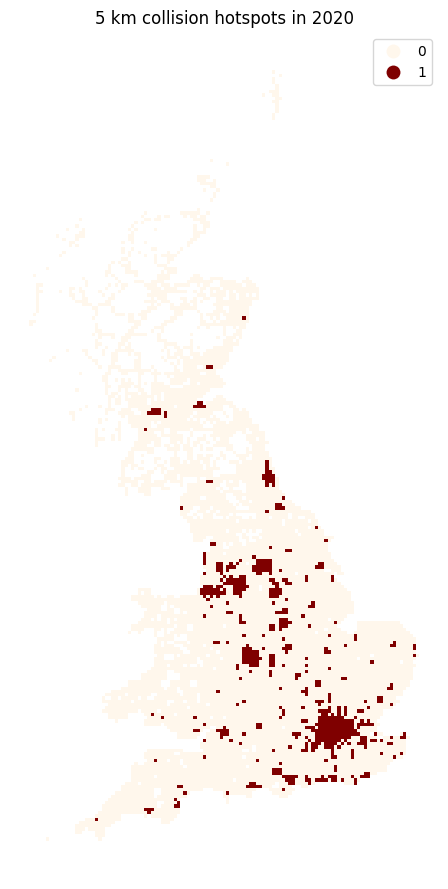

Saved: /content/drive/MyDrive/disseration/stage6_outputs/maps/yearly_hotspots_2020.png


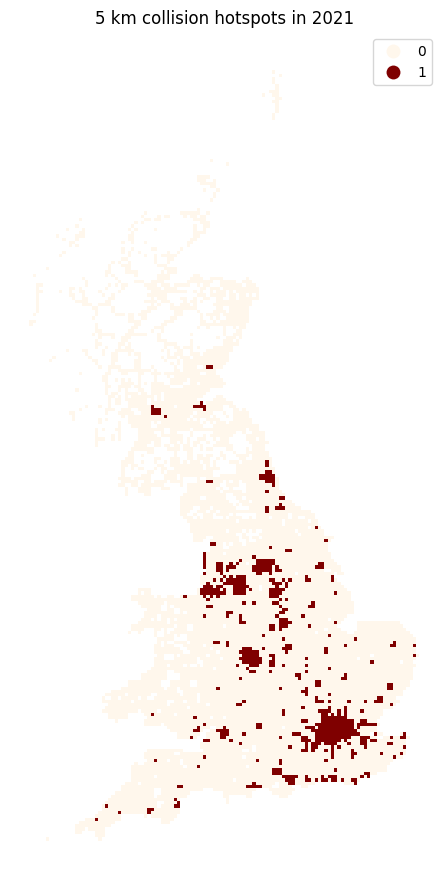

Saved: /content/drive/MyDrive/disseration/stage6_outputs/maps/yearly_hotspots_2021.png


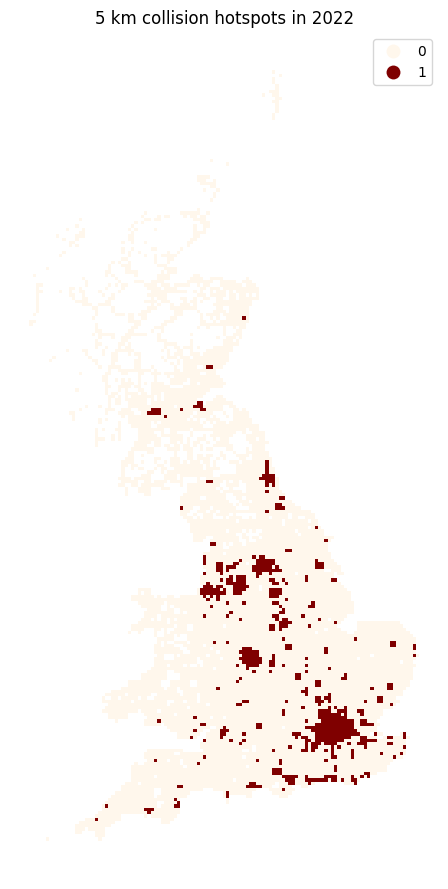

Saved: /content/drive/MyDrive/disseration/stage6_outputs/maps/yearly_hotspots_2022.png


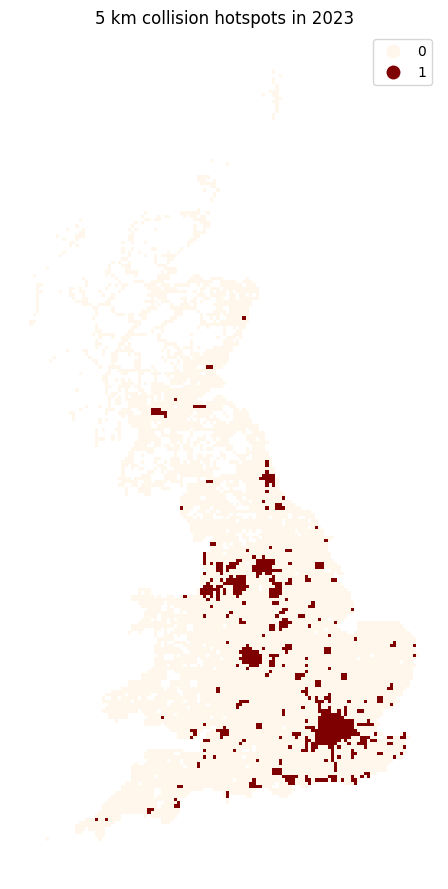

Saved: /content/drive/MyDrive/disseration/stage6_outputs/maps/yearly_hotspots_2023.png


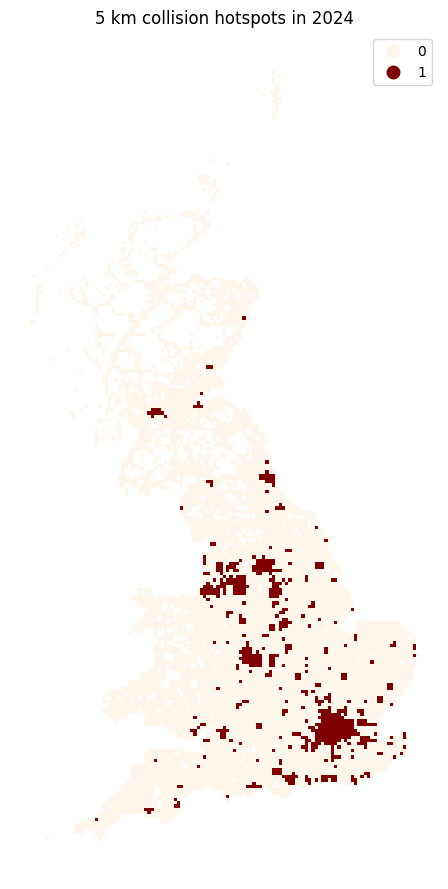

Saved: /content/drive/MyDrive/disseration/stage6_outputs/maps/yearly_hotspots_2024.png


In [59]:
for year in study_years:

    year_data = grid_year[
        grid_year["year"] == year
    ].copy()

    fig, ax = plt.subplots(
        figsize=(9, 11)
    )

    year_data.plot(
        ax=ax,
        column="is_hotspot",
        categorical=True,
        cmap="OrRd",
        legend=True,
        linewidth=0
    )

    ax.set_title(
        f"5 km collision hotspots in {year}"
    )

    ax.set_axis_off()

    map_file = os.path.join(
        map_folder,
        f"yearly_hotspots_{year}.png"
    )

    plt.savefig(
        map_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", map_file)

# Part B: Persistence scoring

Now that the yearly hotspot status has been created, I will measure how often each grid cell was a hotspot.

## 17. Change the hotspot data into wide format

Each grid cell will have one hotspot column for each year.

In [60]:
hotspot_wide = grid_year.pivot(
    index="grid_id",
    columns="year",
    values="is_hotspot"
)

In [61]:
hotspot_wide = hotspot_wide.reindex(
    columns=study_years
)

hotspot_wide = hotspot_wide.reset_index()

hotspot_wide.columns = [
    "grid_id",
    "hotspot_2020",
    "hotspot_2021",
    "hotspot_2022",
    "hotspot_2023",
    "hotspot_2024"
]

hotspot_wide.head()

,grid_id,hotspot_2020,hotspot_2021,hotspot_2022,hotspot_2023,hotspot_2024
0,R000_C005,0,0,0,0,0
1,R000_C021,0,0,0,0,0
2,R001_C020,0,0,0,0,0
3,R001_C021,0,0,0,0,0
4,R001_C022,0,0,0,0,0


In [62]:
hotspot_columns = [
    "hotspot_2020",
    "hotspot_2021",
    "hotspot_2022",
    "hotspot_2023",
    "hotspot_2024"
]

print(
    "Missing hotspot values:",
    hotspot_wide[hotspot_columns]
    .isna()
    .sum()
    .sum()
)

Missing hotspot values: 0


## 18. Count the number of hotspot years

In [63]:
hotspot_wide["hotspot_years"] = (
    hotspot_wide[hotspot_columns]
    .sum(axis=1)
    .astype(int)
)

In [64]:
hotspot_wide[
    ["grid_id", "hotspot_years"]
].head()

,grid_id,hotspot_years
0,R000_C005,0
1,R000_C021,0
2,R001_C020,0
3,R001_C021,0
4,R001_C022,0


## 19. Calculate the persistence score

I am using a simple score:

**Persistence score = hotspot years / 5**

This gives a value from 0 to 1.

In [65]:
hotspot_wide["hotspot_proportion"] = (
    hotspot_wide["hotspot_years"] / 5
)

hotspot_wide["persistence_score"] = (
    hotspot_wide["hotspot_proportion"]
)

In [66]:
hotspot_wide[
    [
        "grid_id",
        "hotspot_years",
        "hotspot_proportion",
        "persistence_score"
    ]
].head()

,grid_id,hotspot_years,hotspot_proportion,persistence_score
0,R000_C005,0,0.000,0.000
1,R000_C021,0,0.000,0.000
2,R001_C020,0,0.000,0.000
3,R001_C021,0,0.000,0.000
4,R001_C022,0,0.000,0.000


## 20. Create persistence categories

I will use:

- 0 years: Never hotspot
- 1 year: Occasional hotspot
- 2 or 3 years: Repeated hotspot
- 4 or 5 years: Persistent hotspot

A persistent hotspot therefore needs to appear in at least 80% of the study years.

In [67]:
persistence_conditions = [
    hotspot_wide["hotspot_years"] == 0,
    hotspot_wide["hotspot_years"] == 1,
    hotspot_wide["hotspot_years"].between(2, 3),
    hotspot_wide["hotspot_years"].between(4, 5)
]

persistence_labels = [
    "Never hotspot",
    "Occasional hotspot",
    "Repeated hotspot",
    "Persistent hotspot"
]

In [68]:
hotspot_wide["persistence_category"] = np.select(
    persistence_conditions,
    persistence_labels,
    default="Check"
)

In [69]:
persistence_summary = (
    hotspot_wide["persistence_category"]
    .value_counts()
    .reindex(
        persistence_labels,
        fill_value=0
    )
    .rename_axis("persistence_category")
    .reset_index(name="grid_cells")
)

persistence_summary["percentage"] = (
    persistence_summary["grid_cells"]
    / len(hotspot_wide)
    * 100
)

persistence_summary.round(2)

,persistence_category,grid_cells,percentage
0,Never hotspot,6844,89.980
1,Occasional hotspot,86,1.130
2,Repeated hotspot,122,1.600
3,Persistent hotspot,554,7.280


## 21. Check consecutive hotspot years

A cell can have several hotspot years without those years being consecutive. I will calculate the longest continuous run.

In [70]:
def find_longest_run(row):

    longest_run = 0
    current_run = 0

    for value in row:

        if value == 1:
            current_run = current_run + 1

            if current_run > longest_run:
                longest_run = current_run

        else:
            current_run = 0

    return longest_run

In [71]:
hotspot_wide["longest_hotspot_run"] = (
    hotspot_wide[hotspot_columns]
    .apply(
        find_longest_run,
        axis=1
    )
)

In [72]:
longest_run_summary = (
    hotspot_wide["longest_hotspot_run"]
    .value_counts()
    .sort_index()
    .rename_axis("longest_hotspot_run")
    .reset_index(name="grid_cells")
)

longest_run_summary

,longest_hotspot_run,grid_cells
0,0,6844
1,1,124
2,2,82
3,3,39
4,4,36
5,5,481


## 22. Compare early and later years

I will compare:

- Early years: 2020 and 2021
- Later years: 2023 and 2024

The year 2022 is treated as the middle year.

In [73]:
hotspot_wide["early_hotspot_years"] = (
    hotspot_wide[
        ["hotspot_2020", "hotspot_2021"]
    ]
    .sum(axis=1)
    .astype(int)
)

hotspot_wide["late_hotspot_years"] = (
    hotspot_wide[
        ["hotspot_2023", "hotspot_2024"]
    ]
    .sum(axis=1)
    .astype(int)
)

In [74]:
hotspot_wide["early_hotspot_rate"] = (
    hotspot_wide["early_hotspot_years"] / 2
)

hotspot_wide["late_hotspot_rate"] = (
    hotspot_wide["late_hotspot_years"] / 2
)

hotspot_wide["hotspot_change_score"] = (
    hotspot_wide["late_hotspot_rate"]
    -
    hotspot_wide["early_hotspot_rate"]
)

In [75]:
hotspot_wide[
    [
        "grid_id",
        "early_hotspot_years",
        "late_hotspot_years",
        "hotspot_change_score"
    ]
].head()

,grid_id,early_hotspot_years,late_hotspot_years,hotspot_change_score
0,R000_C005,0,0,0.000
1,R000_C021,0,0,0.000
2,R001_C020,0,0,0.000
3,R001_C021,0,0,0.000
4,R001_C022,0,0,0.000


## 23. Add the yearly collision counts

This gives me the option to compare the raw collision-count change as well as hotspot-status change.

In [76]:
collision_wide = grid_year.pivot(
    index="grid_id",
    columns="year",
    values="collision_count"
)

collision_wide = collision_wide.reindex(
    columns=study_years
)

collision_wide = collision_wide.reset_index()

collision_wide.columns = [
    "grid_id",
    "collision_count_2020",
    "collision_count_2021",
    "collision_count_2022",
    "collision_count_2023",
    "collision_count_2024"
]

collision_wide.head()

,grid_id,collision_count_2020,collision_count_2021,collision_count_2022,collision_count_2023,collision_count_2024
0,R000_C005,0,0,2,3,2
1,R000_C021,1,1,0,2,0
2,R001_C020,2,4,2,4,2
3,R001_C021,4,2,3,1,0
4,R001_C022,3,4,0,0,1


In [77]:
hotspot_wide = hotspot_wide.merge(
    collision_wide,
    on="grid_id",
    how="left"
)

In [78]:
hotspot_wide["early_mean_collision_count"] = (
    hotspot_wide[
        [
            "collision_count_2020",
            "collision_count_2021"
        ]
    ]
    .mean(axis=1)
)

hotspot_wide["late_mean_collision_count"] = (
    hotspot_wide[
        [
            "collision_count_2023",
            "collision_count_2024"
        ]
    ]
    .mean(axis=1)
)

hotspot_wide["collision_count_change"] = (
    hotspot_wide["late_mean_collision_count"]
    -
    hotspot_wide["early_mean_collision_count"]
)

## 24. Classify the temporal pattern

I will use a simple rule:

- Never hotspot: no hotspot years
- Persistent: hotspot in 4 or 5 years
- Emerging: no hotspot in 2020-2021, but at least one in 2023-2024
- Declining: at least one hotspot in 2020-2021, but none in 2023-2024
- Intermittent: all other cells with at least one hotspot year

In [79]:
pattern_conditions = [
    hotspot_wide["hotspot_years"] == 0,

    hotspot_wide["hotspot_years"] >= 4,

    (
        (hotspot_wide["hotspot_years"] < 4)
        &
        (hotspot_wide["early_hotspot_years"] == 0)
        &
        (hotspot_wide["late_hotspot_years"] >= 1)
    ),

    (
        (hotspot_wide["hotspot_years"] < 4)
        &
        (hotspot_wide["early_hotspot_years"] >= 1)
        &
        (hotspot_wide["late_hotspot_years"] == 0)
    )
]

pattern_labels = [
    "Never hotspot",
    "Persistent",
    "Emerging",
    "Declining"
]

In [80]:
hotspot_wide["pattern_category"] = np.select(
    pattern_conditions,
    pattern_labels,
    default="Intermittent"
)

In [81]:
pattern_order = [
    "Never hotspot",
    "Persistent",
    "Emerging",
    "Declining",
    "Intermittent"
]

pattern_summary = (
    hotspot_wide["pattern_category"]
    .value_counts()
    .reindex(
        pattern_order,
        fill_value=0
    )
    .rename_axis("pattern_category")
    .reset_index(name="grid_cells")
)

pattern_summary["percentage"] = (
    pattern_summary["grid_cells"]
    / len(hotspot_wide)
    * 100
)

pattern_summary.round(2)

,pattern_category,grid_cells,percentage
0,Never hotspot,6844,89.980
1,Persistent,554,7.280
2,Emerging,78,1.030
3,Declining,51,0.670
4,Intermittent,79,1.040


## 25. Create one grid-level geometry table

The yearly geometry repeats five times, so I only need one copy for each grid cell.

In [82]:
grid_geometry = (
    grid_year[
        ["grid_id", "geometry"]
    ]
    .drop_duplicates("grid_id")
    .copy()
)

print("Rows in geometry table:", len(grid_geometry))
print("Unique grid IDs:", grid_geometry["grid_id"].nunique())

Rows in geometry table: 7606
Unique grid IDs: 7606


In [83]:
grid_persistence = grid_geometry.merge(
    hotspot_wide,
    on="grid_id",
    how="left"
)

grid_persistence = gpd.GeoDataFrame(
    grid_persistence,
    geometry="geometry",
    crs=grid_year.crs
)

grid_persistence.head()

,grid_id,geometry,hotspot_2020,hotspot_2021,hotspot_2022,hotspot_2023,hotspot_2024,hotspot_years,hotspot_proportion,persistence_score,persistence_category,longest_hotspot_run,early_hotspot_years,late_hotspot_years,early_hotspot_rate,late_hotspot_rate,hotspot_change_score,collision_count_2020,collision_count_2021,collision_count_2022,collision_count_2023,collision_count_2024,early_mean_collision_count,late_mean_collision_count,collision_count_change,pattern_category
0,R000_C005,"POLYGON ((95000 10000, 95000 15000, 90000 1500...",0,0,0,0,0,0,0.000,0.000,Never hotspot,0,0,0,0.000,0.000,0.000,0,0,2,3,2,0.000,2.500,2.500,Never hotspot
1,R000_C021,"POLYGON ((175000 10000, 175000 15000, 170000 1...",0,0,0,0,0,0,0.000,0.000,Never hotspot,0,0,0,0.000,0.000,0.000,1,1,0,2,0,1.000,1.000,0.000,Never hotspot
2,R001_C020,"POLYGON ((170000 15000, 170000 20000, 165000 2...",0,0,0,0,0,0,0.000,0.000,Never hotspot,0,0,0,0.000,0.000,0.000,2,4,2,4,2,3.000,3.000,0.000,Never hotspot
3,R001_C021,"POLYGON ((175000 15000, 175000 20000, 170000 2...",0,0,0,0,0,0,0.000,0.000,Never hotspot,0,0,0,0.000,0.000,0.000,4,2,3,1,0,3.000,0.500,-2.500,Never hotspot
4,R001_C022,"POLYGON ((180000 15000, 180000 20000, 175000 2...",0,0,0,0,0,0,0.000,0.000,Never hotspot,0,0,0,0.000,0.000,0.000,3,4,0,0,1,3.500,0.500,-3.000,Never hotspot


## 26. Map hotspot frequency

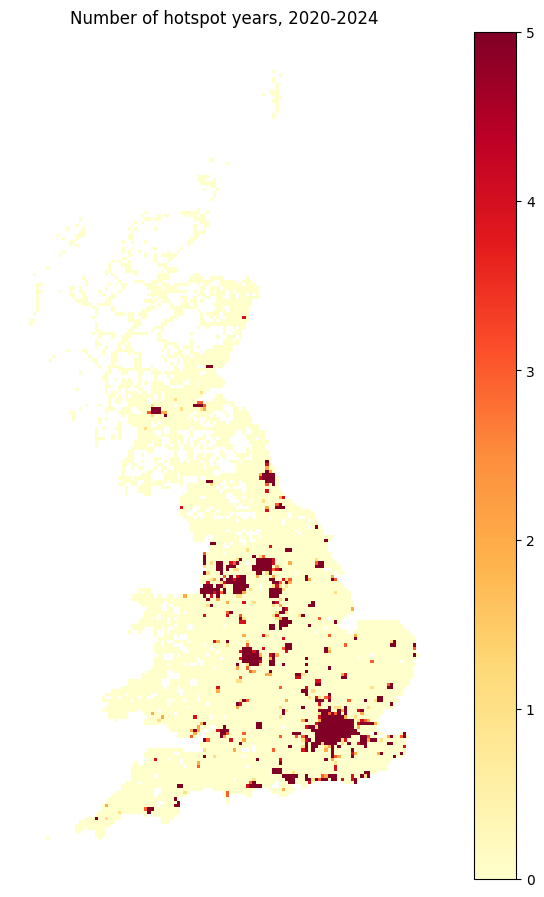

In [84]:
fig, ax = plt.subplots(
    figsize=(9, 11)
)

grid_persistence.plot(
    ax=ax,
    column="hotspot_years",
    cmap="YlOrRd",
    legend=True,
    linewidth=0
)

ax.set_title(
    "Number of hotspot years, 2020-2024"
)

ax.set_axis_off()

frequency_map_file = os.path.join(
    map_folder,
    "hotspot_frequency_2020_2024.png"
)

plt.savefig(
    frequency_map_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 27. Map the persistence score

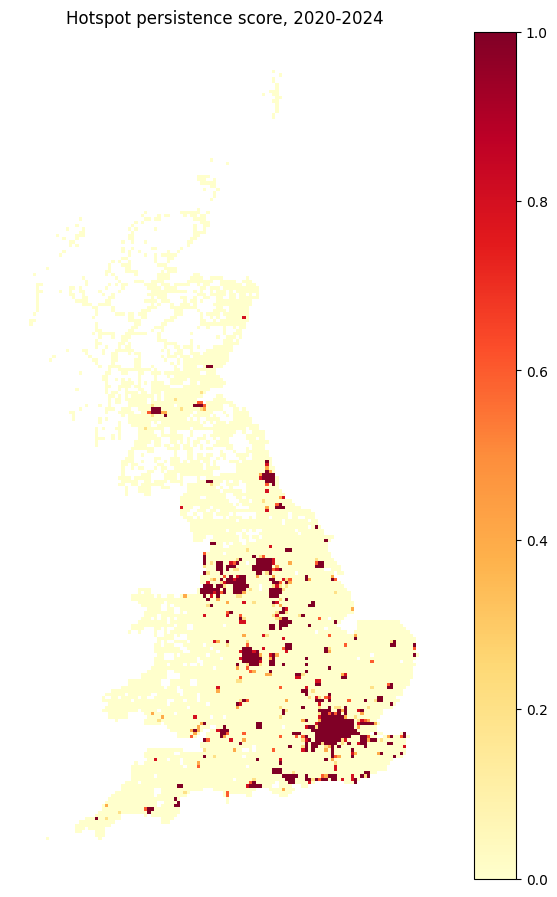

In [85]:
fig, ax = plt.subplots(
    figsize=(9, 11)
)

grid_persistence.plot(
    ax=ax,
    column="persistence_score",
    cmap="YlOrRd",
    legend=True,
    vmin=0,
    vmax=1,
    linewidth=0
)

ax.set_title(
    "Hotspot persistence score, 2020-2024"
)

ax.set_axis_off()

persistence_map_file = os.path.join(
    map_folder,
    "hotspot_persistence_score.png"
)

plt.savefig(
    persistence_map_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 28. Map the temporal pattern categories

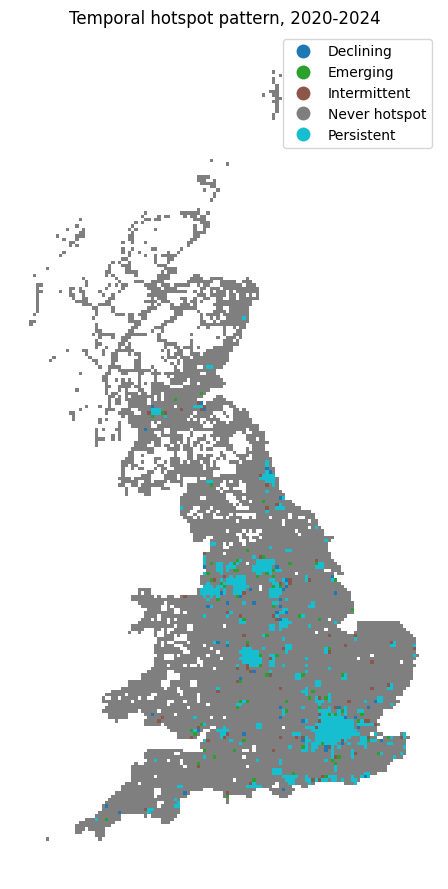

In [86]:
fig, ax = plt.subplots(
    figsize=(9, 11)
)

grid_persistence.plot(
    ax=ax,
    column="pattern_category",
    categorical=True,
    cmap="tab10",
    legend=True,
    linewidth=0
)

ax.set_title(
    "Temporal hotspot pattern, 2020-2024"
)

ax.set_axis_off()

pattern_map_file = os.path.join(
    map_folder,
    "hotspot_pattern_categories.png"
)

plt.savefig(
    pattern_map_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 29. Create final summary tables

In [87]:
hotspot_year_summary = (
    hotspot_wide["hotspot_years"]
    .value_counts()
    .reindex(
        range(0, 6),
        fill_value=0
    )
    .rename_axis("hotspot_years")
    .reset_index(name="grid_cells")
)

hotspot_year_summary["percentage"] = (
    hotspot_year_summary["grid_cells"]
    / len(hotspot_wide)
    * 100
)

hotspot_year_summary.round(2)

,hotspot_years,grid_cells,percentage
0,0,6844,89.980
1,1,86,1.130
2,2,68,0.890
3,3,54,0.710
4,4,73,0.960
5,5,481,6.320


In [88]:
print("Persistence categories")
display(persistence_summary.round(2))

print("\nPattern categories")
display(pattern_summary.round(2))

print("\nYearly hotspot summary")
display(hotspot_summary_by_year.round(2))

Persistence categories


,persistence_category,grid_cells,percentage
0,Never hotspot,6844,89.980
1,Occasional hotspot,86,1.130
2,Repeated hotspot,122,1.600
3,Persistent hotspot,554,7.280



Pattern categories


,pattern_category,grid_cells,percentage
0,Never hotspot,6844,89.980
1,Persistent,554,7.280
2,Emerging,78,1.030
3,Declining,51,0.670
4,Intermittent,79,1.040



Yearly hotspot summary


,year,total_cells,occupied_cells,hotspot_cells,hotspot_pct_all_cells,hotspot_pct_occupied_cells,hotspot_count_threshold,minimum_hotspot_count,mean_hotspot_count,maximum_hotspot_count
0,2020,7606,5947,601,7.900,10.110,32,32,98.200,1182
1,2021,7606,6068,612,8.050,10.090,34,34,109.100,1495
2,2022,7606,6093,610,8.020,10.010,36,36,114.170,1497
3,2023,7606,6135,629,8.270,10.250,35,35,109.110,1409
4,2024,7606,6137,629,8.270,10.250,34,34,104.370,1344


## 30. Final validation checks

I am checking the main value ranges before saving the outputs.

In [89]:
print("Grid-year rows:", len(grid_year))
print("Expected rows:", grid_year["grid_id"].nunique() * 5)
print("Duplicate grid-year rows:", grid_year.duplicated(["grid_id", "year"]).sum())
print("Hotspot values:", sorted(grid_year["is_hotspot"].unique()))
print("Minimum hotspot years:", hotspot_wide["hotspot_years"].min())
print("Maximum hotspot years:", hotspot_wide["hotspot_years"].max())
print("CRS:", grid_persistence.crs)

Grid-year rows: 38030
Expected rows: 38030
Duplicate grid-year rows: 0
Hotspot values: [np.int64(0), np.int64(1)]
Minimum hotspot years: 0
Maximum hotspot years: 5
CRS: EPSG:27700


In [90]:
assert len(grid_year) == (
    grid_year["grid_id"].nunique() * 5
)

assert grid_year.duplicated(
    ["grid_id", "year"]
).sum() == 0

assert grid_year["is_hotspot"].isin(
    [0, 1]
).all()

assert hotspot_wide["hotspot_years"].between(
    0, 5
).all()

assert grid_year.crs.to_epsg() == 27700
assert grid_persistence.crs.to_epsg() == 27700

print("All validation checks passed.")

All validation checks passed.


## 31. Save the Stage 6 datasets

In [91]:
yearly_hotspot_gpkg = os.path.join(
    output_folder,
    "grid_year_hotspots_5km.gpkg"
)

yearly_hotspot_csv = os.path.join(
    output_folder,
    "grid_year_hotspots_5km.csv"
)

persistence_gpkg = os.path.join(
    output_folder,
    "grid_persistence_5km.gpkg"
)

persistence_csv = os.path.join(
    output_folder,
    "grid_persistence_5km.csv"
)

wide_hotspot_csv = os.path.join(
    output_folder,
    "grid_hotspot_status_wide.csv"
)

In [92]:
# Remove old versions if I rerun the notebook

if os.path.exists(yearly_hotspot_gpkg):
    os.remove(yearly_hotspot_gpkg)

if os.path.exists(persistence_gpkg):
    os.remove(persistence_gpkg)

In [93]:
grid_year.to_file(
    yearly_hotspot_gpkg,
    layer="yearly_hotspots",
    driver="GPKG"
)

print("Saved yearly hotspot GeoPackage")

Saved yearly hotspot GeoPackage


In [94]:
# Convert category columns to normal text before saving

grid_persistence["persistence_category"] = (
    grid_persistence["persistence_category"]
    .astype(str)
)

grid_persistence["pattern_category"] = (
    grid_persistence["pattern_category"]
    .astype(str)
)

grid_persistence.to_file(
    persistence_gpkg,
    layer="grid_persistence",
    driver="GPKG"
)

print("Saved persistence GeoPackage")

Saved persistence GeoPackage


In [95]:
grid_year.drop(
    columns="geometry"
).to_csv(
    yearly_hotspot_csv,
    index=False
)

grid_persistence.drop(
    columns="geometry"
).to_csv(
    persistence_csv,
    index=False
)

hotspot_wide.to_csv(
    wide_hotspot_csv,
    index=False
)

print("Saved CSV datasets")

Saved CSV datasets


## 32. Save the summary tables

In [96]:
yearly_count_summary.reset_index().to_csv(
    os.path.join(
        output_folder,
        "yearly_collision_count_summary.csv"
    ),
    index=False
)

zero_by_year.to_csv(
    os.path.join(
        output_folder,
        "zero_collision_summary_by_year.csv"
    ),
    index=False
)

threshold_comparison.to_csv(
    os.path.join(
        output_folder,
        "top10_top5_threshold_comparison.csv"
    ),
    index=False
)

yearly_thresholds.to_csv(
    os.path.join(
        output_folder,
        "hotspot_thresholds_by_year.csv"
    ),
    index=False
)

In [97]:
hotspot_summary_by_year.to_csv(
    os.path.join(
        output_folder,
        "hotspot_summary_by_year.csv"
    ),
    index=False
)

hotspot_year_summary.to_csv(
    os.path.join(
        output_folder,
        "hotspot_year_count_summary.csv"
    ),
    index=False
)

persistence_summary.to_csv(
    os.path.join(
        output_folder,
        "persistence_category_summary.csv"
    ),
    index=False
)

pattern_summary.to_csv(
    os.path.join(
        output_folder,
        "pattern_category_summary.csv"
    ),
    index=False
)

longest_run_summary.to_csv(
    os.path.join(
        output_folder,
        "longest_hotspot_run_summary.csv"
    ),
    index=False
)

print("Saved summary tables")

Saved summary tables


## 33. Check the saved files

In [98]:
for file_name in sorted(
    os.listdir(output_folder)
):
    print(file_name)

grid_hotspot_status_wide.csv
grid_persistence_5km.csv
grid_persistence_5km.gpkg
grid_year_hotspots_5km.csv
grid_year_hotspots_5km.gpkg
hotspot_summary_by_year.csv
hotspot_thresholds_by_year.csv
hotspot_year_count_summary.csv
longest_hotspot_run_summary.csv
maps
pattern_category_summary.csv
persistence_category_summary.csv
top10_top5_threshold_comparison.csv
yearly_collision_count_summary.csv
zero_collision_summary_by_year.csv


# Stage 6 working summary

In this stage I used the Stage 5 5 km grid-year dataset and classified yearly collision hotspots.

I first checked the yearly distribution and compared top 10% and top 5% thresholds. I selected the top 10% of occupied cells in each year because it gave a more useful and stable number of hotspot cells for later analysis.

A yearly hotspot score and binary hotspot variable were created. I then counted the number of hotspot years for every grid cell and calculated a persistence score by dividing the number of hotspot years by five.

Grid cells were classified as never, occasional, repeated or persistent hotspots. I also calculated the longest consecutive hotspot run.

To examine change over time, I compared 2020-2021 with 2023-2024 and classified cells as persistent, emerging, declining, intermittent or never hotspots.

The main limitations are that the threshold is relative, tied counts can slightly increase the hotspot percentage, five years is a short study period, and the results depend on the 5 km grid size. This method also does not test spatial statistical significance.

The Stage 6 CSV and GeoPackage files are now ready for Stage 7 statistical modelling.

## Additional check: Why I used a yearly relative hotspot threshold

The main hotspot definition in this project uses the 90th percentile of occupied grid cells separately within each year.

I want to check this decision more explicitly because annual collision totals are not constant across the study period. A single fixed collision-count threshold would assume that the same raw collision count has the same relative meaning in every year.

This may be problematic across 2020–2024 because the overall collision distribution can change between years. For example, the study period includes the COVID-19 period and subsequent changes in travel activity.

I am therefore comparing my yearly 90th-percentile threshold with a simple fixed threshold. This is only a sensitivity check. I am not replacing the main hotspot definition.

In [99]:
# First I want to see how the overall collision totals changed by year.

annual_collision_summary = (
    grid_year
    .groupby("year")
    .agg(
        total_collisions=("collision_count", "sum"),
        occupied_cells=(
            "collision_count",
            lambda x: (x > 0).sum()
        ),
        mean_collisions_per_cell=(
            "collision_count",
            "mean"
        ),
        median_collisions_per_cell=(
            "collision_count",
            "median"
        )
    )
    .reset_index()
)

annual_collision_summary

,year,total_collisions,occupied_cells,mean_collisions_per_cell,median_collisions_per_cell
0,2020,91185,5947,11.989,3.000
1,2021,101070,6068,13.288,3.000
2,2022,105982,6093,13.934,3.000
3,2023,104246,6135,13.706,3.000
4,2024,100927,6137,13.269,3.000


In [100]:
annual_collision_summary["change_from_previous_year_pct"] = (
    annual_collision_summary["total_collisions"]
    .pct_change() * 100
)

annual_collision_summary.round(2)

,year,total_collisions,occupied_cells,mean_collisions_per_cell,median_collisions_per_cell,change_from_previous_year_pct
0,2020,91185,5947,11.990,3.000,NaN
1,2021,101070,6068,13.290,3.000,10.840
2,2022,105982,6093,13.930,3.000,4.860
3,2023,104246,6135,13.710,3.000,-1.640
4,2024,100927,6137,13.270,3.000,-3.180


In [102]:
#yearly dynamic thresholds beside annual collision totals
dynamic_threshold_check = (
    annual_collision_summary
    .merge(
        yearly_thresholds,
        on="year",
        how="left"
    )
)

dynamic_threshold_check.round(2)

,year,total_collisions,occupied_cells,mean_collisions_per_cell,median_collisions_per_cell,change_from_previous_year_pct,hotspot_count_threshold
0,2020,91185,5947,11.990,3.000,NaN,32
1,2021,101070,6068,13.290,3.000,10.840,34
2,2022,105982,6093,13.930,3.000,4.860,36
3,2023,104246,6135,13.710,3.000,-1.640,35
4,2024,100927,6137,13.270,3.000,-3.180,34


Plot annual collisions and threshold separately
First, total collisions:

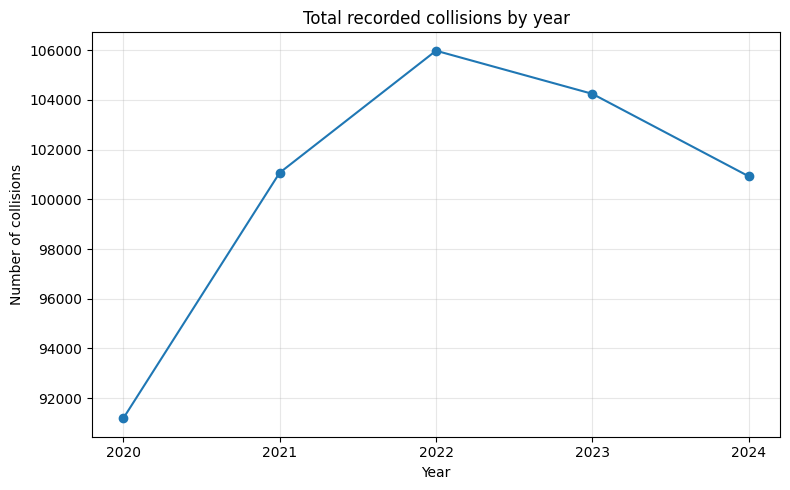

In [103]:
plt.figure(figsize=(8, 5))

plt.plot(
    dynamic_threshold_check["year"],
    dynamic_threshold_check["total_collisions"],
    marker="o"
)

plt.title("Total recorded collisions by year")
plt.xlabel("Year")
plt.ylabel("Number of collisions")
plt.xticks(study_years)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

actual hotspot thresholds:

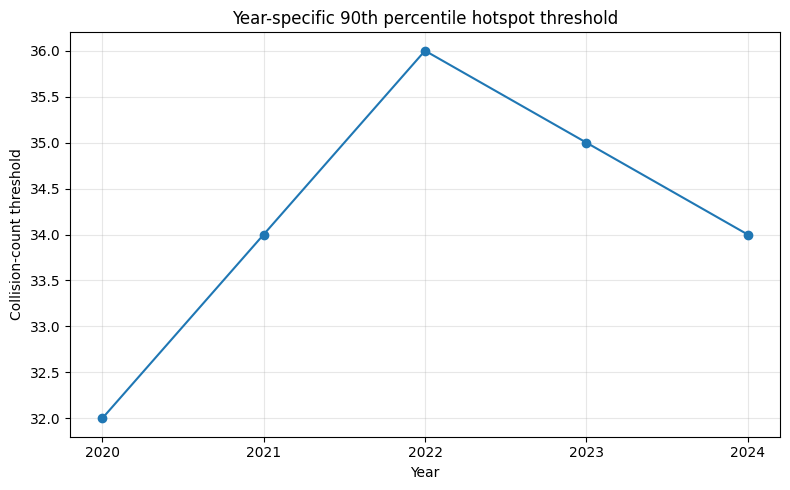

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(
    dynamic_threshold_check["year"],
    dynamic_threshold_check["hotspot_count_threshold"],
    marker="o"
)

plt.title("Year-specific 90th percentile hotspot threshold")
plt.xlabel("Year")
plt.ylabel("Collision-count threshold")
plt.xticks(study_years)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [105]:
# Fixed comparison threshold
# This uses one 90th-percentile value for the whole 2020-2024 period.

all_occupied_counts = grid_year.loc[
    grid_year["collision_count"] > 0,
    "collision_count"
]

fixed_threshold = int(
    all_occupied_counts.quantile(
        0.90,
        interpolation="higher"
    )
)

print(
    "Single fixed 90th-percentile collision threshold:",
    fixed_threshold
)

Single fixed 90th-percentile collision threshold: 34


In [106]:
grid_year["fixed_threshold_hotspot"] = (
    (
        grid_year["collision_count"] > 0
    )
    &
    (
        grid_year["collision_count"] >= fixed_threshold
    )
).astype(int)

In [107]:
grid_year[
    [
        "grid_id",
        "year",
        "collision_count",
        "hotspot_count_threshold",
        "is_hotspot",
        "fixed_threshold_hotspot"
    ]
].head(10)

,grid_id,year,collision_count,hotspot_count_threshold,is_hotspot,fixed_threshold_hotspot
0,R000_C005,2020,0,32,0,0
1,R000_C005,2021,0,34,0,0
2,R000_C005,2022,2,36,0,0
3,R000_C005,2023,3,35,0,0
4,R000_C005,2024,2,34,0,0
5,R000_C021,2020,1,32,0,0
6,R000_C021,2021,1,34,0,0
7,R000_C021,2022,0,36,0,0
8,R000_C021,2023,2,35,0,0
9,R000_C021,2024,0,34,0,0


Compare dynamic vs fixed classification by year

In [108]:
threshold_method_comparison = (
    grid_year
    .groupby("year")
    .agg(
        total_cells=("grid_id", "size"),
        occupied_cells=(
            "collision_count",
            lambda x: (x > 0).sum()
        ),
        dynamic_hotspots=("is_hotspot", "sum"),
        fixed_hotspots=(
            "fixed_threshold_hotspot",
            "sum"
        )
    )
    .reset_index()
)

In [109]:
threshold_method_comparison[
    "dynamic_pct_of_occupied"
] = (
    threshold_method_comparison["dynamic_hotspots"]
    /
    threshold_method_comparison["occupied_cells"]
    * 100
)

threshold_method_comparison[
    "fixed_pct_of_occupied"
] = (
    threshold_method_comparison["fixed_hotspots"]
    /
    threshold_method_comparison["occupied_cells"]
    * 100
)

threshold_method_comparison.round(2)

,year,total_cells,occupied_cells,dynamic_hotspots,fixed_hotspots,dynamic_pct_of_occupied,fixed_pct_of_occupied
0,2020,7606,5947,601,558,10.110,9.380
1,2021,7606,6068,612,612,10.090,10.090
2,2022,7606,6093,610,640,10.010,10.500
3,2023,7606,6135,629,639,10.250,10.420
4,2024,7606,6137,629,629,10.250,10.250


In [110]:
#Add annual collision totals to the comparison
threshold_method_comparison = (
    threshold_method_comparison
    .merge(
        annual_collision_summary[
            ["year", "total_collisions"]
        ],
        on="year",
        how="left"
    )
)

threshold_method_comparison[
    [
        "year",
        "total_collisions",
        "occupied_cells",
        "dynamic_hotspots",
        "dynamic_pct_of_occupied",
        "fixed_hotspots",
        "fixed_pct_of_occupied"
    ]
].round(2)


,year,total_collisions,occupied_cells,dynamic_hotspots,dynamic_pct_of_occupied,fixed_hotspots,fixed_pct_of_occupied
0,2020,91185,5947,601,10.110,558,9.380
1,2021,101070,6068,612,10.090,612,10.090
2,2022,105982,6093,610,10.010,640,10.500
3,2023,104246,6135,629,10.250,639,10.420
4,2024,100927,6137,629,10.250,629,10.250


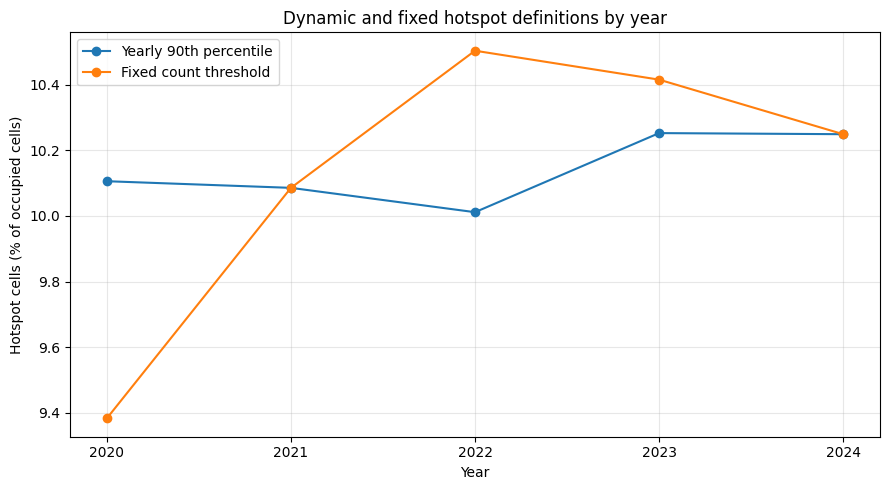

In [111]:
#Graph the difference
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_method_comparison["year"],
    threshold_method_comparison["dynamic_pct_of_occupied"],
    marker="o",
    label="Yearly 90th percentile"
)

plt.plot(
    threshold_method_comparison["year"],
    threshold_method_comparison["fixed_pct_of_occupied"],
    marker="o",
    label="Fixed count threshold"
)

plt.title("Dynamic and fixed hotspot definitions by year")
plt.xlabel("Year")
plt.ylabel("Hotspot cells (% of occupied cells)")
plt.xticks(study_years)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [112]:
#Quantify how stable each method is
dynamic_variation = (
    threshold_method_comparison[
        "dynamic_pct_of_occupied"
    ].std()
)

fixed_variation = (
    threshold_method_comparison[
        "fixed_pct_of_occupied"
    ].std()
)

print(
    "Variation in yearly hotspot percentage"
)

print(
    "Dynamic yearly threshold:",
    round(dynamic_variation, 2)
)

print(
    "Fixed collision threshold:",
    round(fixed_variation, 2)
)

Variation in yearly hotspot percentage
Dynamic yearly threshold: 0.11
Fixed collision threshold: 0.45


In [113]:
if dynamic_variation < fixed_variation:
    print(
        "\nThe yearly relative threshold gives a more consistent "
        "hotspot proportion across years than the fixed threshold."
    )
else:
    print(
        "\nThe difference in yearly hotspot proportions is small, "
        "so the threshold choice should be interpreted cautiously."
    )


The yearly relative threshold gives a more consistent hotspot proportion across years than the fixed threshold.


In [114]:
#Check how much the two methods disagree
grid_year["threshold_methods_disagree"] = (
    grid_year["is_hotspot"]
    !=
    grid_year["fixed_threshold_hotspot"]
).astype(int)

threshold_disagreement = (
    grid_year
    .groupby("year")
    .agg(
        different_classifications=(
            "threshold_methods_disagree",
            "sum"
        ),
        total_cells=("grid_id", "size")
    )
    .reset_index()
)

threshold_disagreement[
    "different_pct"
] = (
    threshold_disagreement["different_classifications"]
    /
    threshold_disagreement["total_cells"]
    * 100
)

threshold_disagreement.round(2)

,year,different_classifications,total_cells,different_pct
0,2020,43,7606,0.570
1,2021,0,7606,0.000
2,2022,30,7606,0.390
3,2023,10,7606,0.130
4,2024,0,7606,0.000


In [115]:
print("Threshold sensitivity check")
print("---------------------------")

print(
    f"The fixed comparison threshold across all years is "
    f"{fixed_threshold} collisions."
)

print(
    "My main method instead recalculates the 90th percentile "
    "within each year."
)

print(
    "This allows the hotspot cut-off to respond to changes in "
    "the annual collision-count distribution rather than assuming "
    "that one raw collision count has the same relative meaning "
    "throughout 2020-2024."
)

print(
    "The comparison with the fixed threshold is a sensitivity "
    "check only. The yearly relative threshold remains the main "
    "hotspot definition."
)

Threshold sensitivity check
---------------------------
The fixed comparison threshold across all years is 34 collisions.
My main method instead recalculates the 90th percentile within each year.
This allows the hotspot cut-off to respond to changes in the annual collision-count distribution rather than assuming that one raw collision count has the same relative meaning throughout 2020-2024.
The comparison with the fixed threshold is a sensitivity check only. The yearly relative threshold remains the main hotspot definition.


### Interpretation of annual changes

The 2020–2024 study period covers years in which wider travel conditions changed substantially, including the COVID-19 period and subsequent recovery.

The purpose of the yearly relative threshold is not to estimate the effect of COVID-19 or changes in traffic exposure. Vehicle-kilometre exposure data are not available in this analysis.

Instead, recalculating the 90th percentile within each year allows the hotspot definition to adapt when the observed collision-count distribution changes. This avoids treating one fixed collision count as having exactly the same relative importance in every year.

### Important interpretation limitation

The hotspot classification represents **relative collision concentration**, not exposure-adjusted road risk.

A grid cell may record more collisions partly because it carries more traffic. Vehicle-kilometres travelled or another consistent traffic-exposure denominator was not available at the 5 km grid-year level for this analysis.

For this reason, terms such as **collision hotspot**, **high collision concentration** and **persistent hotspot** are used rather than claiming that these cells are necessarily the most dangerous or highest-risk locations.

In [117]:
dynamic_threshold_check.to_csv(
    os.path.join(
        output_folder,
        "dynamic_threshold_yearly_check.csv"
    ),
    index=False
)

threshold_method_comparison.to_csv(
    os.path.join(
        output_folder,
        "dynamic_vs_fixed_threshold_comparison.csv"
    ),
    index=False
)

threshold_disagreement.to_csv(
    os.path.join(
        output_folder,
        "threshold_method_disagreement.csv"
    ),
    index=False
)

print("Supervisor-feedback threshold checks saved.")

Supervisor-feedback threshold checks saved.


Why 90th percentile instead of 95th percentile?

Because top 10% gives a less sparse and more usable hotspot class while remaining selective.

Why calculate 90th percentile separately every year?

Because the collision distribution varies over time. A relative threshold maintains the meaning of high collision concentration relative to that year.

Why not a fixed collision count?

Because a fixed count can become easier or harder to exceed depending on overall annual collision conditions.

What does this NOT mean?

It does not make collision count equivalent to true road risk and does not adjust for vehicle exposure.